# Joint event-censoring recovery: DVFM vs HACSurv (paired)

Standalone so it does not touch `semi_synthetic_results.ipynb`. Setup cells are
copied verbatim from that notebook, so preprocessing cannot diverge.

Both models are fitted to the identical cohort and split within a seed, so they
are compared **paired**, as a log2 ISE ratio. That cancels dataset difficulty,
which otherwise dominates the display: FLChain alone carries an ISE 6.6x the
next largest dataset's, and an unpaired mean +/- SD across datasets says more
about which datasets are hard than about which model is better.

Writes `semi_synthetic_joint_recovery_ratio_by_{copula,dataset}.pdf`.

In [21]:
from pathlib import Path
import os
import re
import shutil
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "savefig.bbox": "tight",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
})

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
CONFIG_PATH = ROOT / "configs" / "semi_synthetic.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)
RESULT_CANDIDATES = [ROOT / "results" / "semi-synthetic"]
FIGURE_DIR = ROOT / "paper" / "figures"
TABLE_DIR = ROOT / "paper" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
RANK_TAU = 0.5  # prediction results are reported at this dependence level only

# Display names for dataset slugs, in the order datasets are shown in figures;
# anything unmapped falls back to the slug with its underscores escaped, since
# text.usetex is on.
DATASET_LABEL = {
    "whas": "WHAS",
    "metabric": "METABRIC",
    "churn": "Churn",
    "gbsg": "GBSG",
    "nacd": "NACD",
    "flchain": "FLChain",
    "support": "SUPPORT",
    "employee": "Employee",
    "mimic_all": "MIMIC-IV",
    "mimic_iv": "MIMIC-IV",
    "seer_brain": "SEER (brain)",
    "seer_liver": "SEER (liver)",
    "seer_stomach": "SEER (stomach)",
}

def dataset_label(name):
    return DATASET_LABEL.get(str(name), str(name).replace("_", r"\_"))

def order_datasets(names):
    """Figure order: DATASET_LABEL key order, then anything unmapped, alphabetically."""
    observed = {str(name) for name in names}
    ordered = [name for name in DATASET_LABEL if name in observed]
    return ordered + sorted(observed.difference(ordered))

In [22]:
def snake_case(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

def canonicalize(frame):
    out = frame.rename(columns={column: snake_case(column) for column in frame.columns}).copy()
    aliases = {
        "dataset_name": "dataset", "target_censoring": "target_censoring_rate",
        "censoring_rate": "target_censoring_rate", "kendall_tau": "target_kendall_tau",
        "oracle_joint_ise": "oracle_joint_survival_ise",
    }
    out = out.rename(columns={key: value for key, value in aliases.items() if key in out and value not in out})
    if "model" in out:
        names = {"dvfm": "DVFM", "coxph": "CoxPH", "deepsurv": "DeepSurv", "rsf": "RSF",
                 "gbsa": "GBSA", "mtlr": "MTLR", "hacsurv": "HACSurv",
                 "hacsurv_2d": "HACSurv", "clayton_aft": "ClaytonAFT",
                 "bayesian_cox_gamma_frailty": "BayesianCoxGammaFrailty", "bayesiancoxgammafrailty": "BayesianCoxGammaFrailty"}
        out["model"] = out["model"].astype(str).str.lower().map(names).fillna(out["model"].astype(str))
        if "latent_dim" in out:
            latent_dim = pd.to_numeric(out["latent_dim"], errors="coerce")
            nonprimary = out["model"].eq("DVFM") & latent_dim.ne(1) & latent_dim.notna()
            out.loc[nonprimary, "model"] = latent_dim.loc[nonprimary].map(lambda value: f"DVFM-z{int(value)}")
    if "copula" in out:
        out["copula"] = out["copula"].astype(str).str.title()
    return out

result_path = next((path / "results_raw.csv" for path in RESULT_CANDIDATES if (path / "results_raw.csv").exists()), None)
if result_path is not None:
    results = canonicalize(pd.read_csv(result_path))
    DATA_SOURCE = "REAL RESULTS (cross-dataset aggregate)"
else:
    dataset_result_paths = [
        result for root in RESULT_CANDIDATES if root.exists()
        for result in sorted(root.glob("*/results_raw.csv"))
    ]
    if not dataset_result_paths:
        searched = ", ".join(str(path.relative_to(ROOT)) for path in RESULT_CANDIDATES)
        raise FileNotFoundError(f"No semi-synthetic results found in: {searched}")
    results = canonicalize(pd.concat((pd.read_csv(path) for path in dataset_result_paths), ignore_index=True))
    DATA_SOURCE = f"REAL RESULTS ({len(dataset_result_paths)} completed dataset jobs)"

required = {"dataset", "copula", "target_kendall_tau", "target_censoring_rate", "repeat", "model", "oracle_ibs"}
missing = required - set(results.columns)
if missing:
    raise ValueError(f"Results are missing canonical columns: {sorted(missing)}")

# The DVFM z=0 ablation is an internal control fitted alongside z=1; it is
# not one of the joint-surface exporters this notebook pairs.
ABLATION_MODELS = ["DVFM-z0"]
results = results[~results["model"].isin(ABLATION_MODELS)].copy()

CONFIG_TAU_VALUES = [float(value) for value in config["data"]["kendall_tau"]]
CONFIG_POSITIVE_COPULAS = {name.title() for name in config["data"]["copulas"]}
tau = pd.to_numeric(results["target_kendall_tau"], errors="coerce")
configured_tau = np.isclose(tau.to_numpy()[:, None], np.asarray(CONFIG_TAU_VALUES)).any(axis=1)
configured_copula = (np.isclose(tau, 0.0) & results["copula"].eq("Independence")) \
| (~np.isclose(tau, 0.0) & results["copula"].isin(CONFIG_POSITIVE_COPULAS))
results = results.loc[configured_tau & configured_copula].copy()
if results.empty:
    raise ValueError("No rows match the active semi_synthetic.yaml condition grid.")

dataset_specs = {item["name"]: item for item in config["data"]["datasets"]}
characteristics = (
    results.groupby("dataset", as_index=False)
    .agg(**{"$N$": ("num_samples", "median"),
            "Encoded features": ("num_features", "median"),
            "Original censoring rate": ("target_censoring_rate", "median")})
    .rename(columns={"dataset": "Dataset"})
)
characteristics["Raw features"] = characteristics["Dataset"].map(
    lambda name: len(dataset_specs[name].get("numeric_features", [])) + len(dataset_specs[name].get("categorical_features", []))
)
characteristics["Split"] = "70/10/20"
characteristics = characteristics[["Dataset", "$N$", "Raw features", "Encoded features", "Original censoring rate", "Split"]]
for column in ["$N$", "Raw features", "Encoded features"]:
    characteristics[column] = characteristics[column].round().astype(int)

print(DATA_SOURCE, f"| rows={len(results):,} | datasets={results['dataset'].nunique()}")

REAL RESULTS (cross-dataset aggregate) | rows=4,800 | datasets=12


In [23]:
# Same copula ordering as the main results notebook.
copula_order = ["Independence"] + [name.title() for name in config["data"]["copulas"]]
print(copula_order)

['Independence', 'Gaussian', 'Clayton', 'Frank', 'Gumbel']


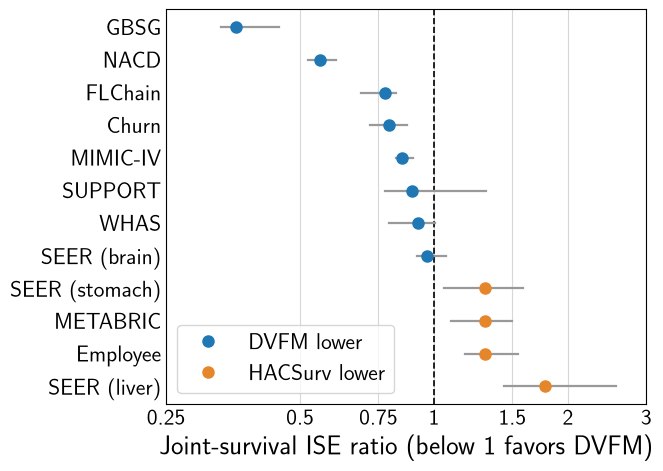

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_joint_recovery_ratio_by_copula.pdf and c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_joint_recovery_ratio_by_dataset.pdf
dataset-balanced mean ISE: DVFM=0.0389 HACSurv=0.0469
DVFM lower in 37/60 dataset x copula cells (paired Wilcoxon W=702, p=0.117)
pooled ISE ratio 0.91 [95% CI 0.82, 1.02]; sign agrees across all copulas on 9/12 datasets


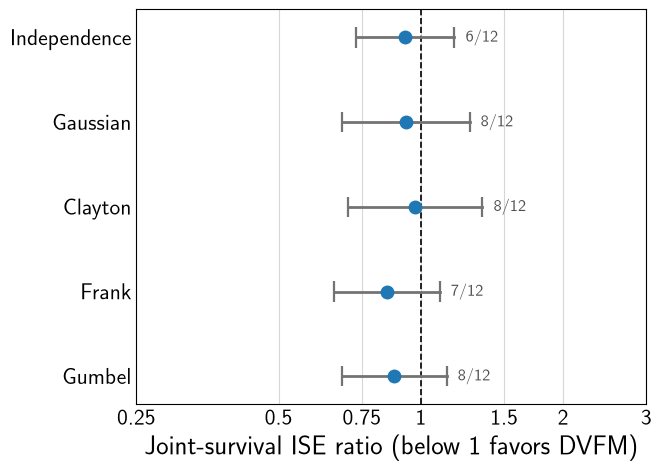

In [24]:
JOINT_METRIC = "oracle_joint_survival_ise"
JOINT_MODELS = ("DVFM", "HACSurv")
WIN, LOSS = "#1f77b4", "#e6862a"          # DVFM better / HACSurv better
XLABEL = "Joint-survival ISE ratio (below 1 favors DVFM)"
RATIO_TICKS = [0.25, 0.5, 0.75, 1, 1.5, 2, 3]

joint = results[results[JOINT_METRIC].notna() & results["model"].isin(JOINT_MODELS)].copy()
if joint.empty:
    raise ValueError(f"No {JOINT_METRIC} rows for {JOINT_MODELS}.")
exporters = sorted(results.loc[results[JOINT_METRIC].notna(), "model"].unique())
if set(exporters) - set(JOINT_MODELS):
    raise ValueError(f"{JOINT_METRIC} now has extra exporters: {exporters}; widen JOINT_MODELS.")

# Average the repeat/fold runs first so every dataset x copula cell weighs equally.
joint_cells = joint.groupby(["dataset", "copula", "model"], as_index=False)[JOINT_METRIC].mean()
counts = joint_cells.groupby("model").size()
if counts.nunique() != 1:
    raise ValueError(f"Unbalanced cell grid across models: {counts.to_dict()}")

joint_copula_order = [name for name in copula_order if name in set(joint_cells["copula"])]

# Both models are fitted to the identical cohort and split, so compare them paired.
# Means and intervals are computed on the log ratio, which is symmetric, then shown
# on a ratio axis so the reader sees "half the error" rather than "minus one".
# Pairing cancels dataset difficulty, which otherwise dominates: FLChain alone
# carries an ISE 6.6x the next largest, so an unpaired mean +/- SD across datasets
# says more about which datasets are hard than about which model is better.
paired = joint_cells.pivot_table(index=["dataset", "copula"], columns="model", values=JOINT_METRIC)
if paired.isna().any().any():
    raise ValueError("Unpaired dataset x copula cell.")
paired["lr"] = np.log2(paired["DVFM"] / paired["HACSurv"])


# Colour carries the verdict, so it needs a key once, on the dataset panel.
LEGEND_HANDLES = [
    plt.Line2D([], [], marker="o", linestyle="none", markersize=8, color=WIN,
               label="DVFM lower"),
    plt.Line2D([], [], marker="o", linestyle="none", markersize=8, color=LOSS,
               label="HACSurv lower"),
]


def ratio_axis(axis, legend_loc=None):
    """Log-spaced ratio axis: equal visual distance for halving and doubling."""
    axis.set_xscale("log", base=2)
    if legend_loc is not None:
        axis.legend(handles=LEGEND_HANDLES, loc=legend_loc, frameon=True)
    axis.set_xticks(RATIO_TICKS, [f"{tick:g}" for tick in RATIO_TICKS])
    axis.axvline(1.0, color="black", linewidth=1.2, linestyle="--", zorder=1)
    axis.set(xlabel=XLABEL)
    axis.grid(axis="x", alpha=0.5)
    axis.set_axisbelow(True)
    axis.invert_yaxis()


# Two figures at one size so they drop into a LaTeX subfigure pair.
JOINT_PANEL_SIZE = (6.5, 4.6)

# -- panel (a): by dataset, mean with the min-max range across the five copulas --
fig_dot, ax_dot = plt.subplots(figsize=JOINT_PANEL_SIZE, constrained_layout=True)
by_dataset = paired.groupby("dataset")["lr"].agg(["mean", "min", "max"]).sort_values("mean")
positions = np.arange(len(by_dataset))
for y, (_, row) in zip(positions, by_dataset.iterrows()):
    ax_dot.plot([2 ** row["min"], 2 ** row["max"]], [y, y], color="0.6", linewidth=1.6, zorder=2)
    ax_dot.plot(2 ** row["mean"], y, "o", markersize=8,
                color=WIN if row["mean"] < 0 else LOSS, zorder=3)
ax_dot.set_yticks(positions, [dataset_label(name) for name in by_dataset.index])
ratio_axis(ax_dot, "lower left")

out_dot = FIGURE_DIR / "semi_synthetic_joint_recovery_ratio_by_dataset.pdf"
fig_dot.savefig(out_dot, bbox_inches="tight")
plt.show()

# -- panel (b): by copula, mean over the datasets with a 95% interval --
fig_bar, ax_bar = plt.subplots(figsize=JOINT_PANEL_SIZE, constrained_layout=True)
copula_rows = []
for name in joint_copula_order:
    values = paired.xs(name, level="copula")["lr"].to_numpy()
    standard_error = values.std(ddof=1) / np.sqrt(len(values))
    low, high = scipy.stats.t.interval(
        0.95, len(values) - 1, loc=values.mean(), scale=standard_error
    )
    copula_rows.append((name, values.mean(), low, high, int((values < 0).sum()), len(values)))
positions = np.arange(len(copula_rows))
for y, (_, mean, low, high, wins, total) in zip(positions, copula_rows):
    ax_bar.plot([2 ** low, 2 ** high], [y, y], color="0.45", linewidth=2.0, zorder=2)
    ax_bar.vlines([2 ** low, 2 ** high], y - 0.12, y + 0.12, color="0.45", linewidth=1.6, zorder=2)
    ax_bar.plot(2 ** mean, y, "o", markersize=9, color=WIN if mean < 0 else LOSS, zorder=3)
    # Datasets favoring DVFM, so the interval is read alongside the count behind it.
    ax_bar.annotate(rf"{wins}/{total}", (2 ** high, y), xytext=(8, 0),
                    textcoords="offset points", va="center", fontsize=12, color="0.3")
ax_bar.set_yticks(positions, [row[0] for row in copula_rows])
ratio_axis(ax_bar)

out_bar = FIGURE_DIR / "semi_synthetic_joint_recovery_ratio_by_copula.pdf"
fig_bar.savefig(out_bar, bbox_inches="tight")

# -- paired summary over the dataset x copula cells --
statistic, p_value = scipy.stats.wilcoxon(paired["DVFM"], paired["HACSurv"])
pooled = paired["lr"].to_numpy()
pooled_low, pooled_high = scipy.stats.t.interval(
    0.95, len(pooled) - 1, loc=pooled.mean(), scale=pooled.std(ddof=1) / np.sqrt(len(pooled))
)
unanimous = paired.groupby("dataset")["lr"].apply(lambda s: s.lt(0).all() or s.gt(0).all()).sum()
n_datasets = paired.index.get_level_values("dataset").nunique()
print(f"{DATA_SOURCE} | wrote {out_bar} and {out_dot}")
print(f"dataset-balanced mean ISE: DVFM={paired['DVFM'].mean():.4f} HACSurv={paired['HACSurv'].mean():.4f}")
print(f"DVFM lower in {paired['lr'].lt(0).sum()}/{len(paired)} dataset x copula cells "
      f"(paired Wilcoxon W={statistic:g}, p={p_value:.3f})")
print(f"pooled ISE ratio {2 ** pooled.mean():.2f} "
      f"[95% CI {2 ** pooled_low:.2f}, {2 ** pooled_high:.2f}]; "
      f"sign agrees across all copulas on {unanimous}/{n_datasets} datasets")